# Building Block Selection & Library Analysis — Skin Permeability Focused Approach

**Goal:** Select building blocks from ChEMBL structurally similar to molecules with known skin permeability, generate a combinatorial library, and predict skin permeability of the resulting compounds.

**Method:** Morgan fingerprints (radius=2, 2048 bits) + Tanimoto similarity ≥ 0.8

**What are Morgan fingerprints?**
A fingerprint represents a molecule as a series of 0s and 1s. Morgan fingerprints encode each atom's chemical environment up to a given radius. Two similar molecules share many bits. Tanimoto similarity measures the fraction of shared bits:
> Tanimoto = (shared bits) / (total bits in either molecule)
> 
> Tanimoto = 1.0 → identical molecules | Tanimoto = 0.8 → 80% structural similarity

---
## Pipeline Overview
1. Load and visualize skin permeability reference datasets
2. Load ChEMBL building blocks
3. Tanimoto similarity filtering
4. Visualize focused BB set
5. Synt-On classification results
6. Enumerated library analysis
7. Skin permeability predictions

## 1. Imports

In [2]:
import pandas as pd
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors
from rdkit.Chem.Draw import MolsToGridImage
from IPython.display import display
from tqdm import tqdm
import matplotlib.pyplot as plt
import os

output_dir = '/home/nubar/Downloads/Internship_Chemoinfo/01_data/processed'
results_dir = '/home/nubar/Downloads/Internship_Chemoinfo/04_results'
os.makedirs(output_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

print('Imports OK')

Imports OK


## 2. Load and visualize skin permeability reference datasets

Three curated datasets are combined:
- **HuskinDB** — 129 molecules with experimental logKp values
- **SkinPiX** — 103 molecules with experimental logKp values
- **INRS** — 3 molecules measured after model construction

These are the reference molecules used for Tanimoto-based BB selection.

In [3]:
huskin  = pd.read_csv('/home/nubar/Downloads/Internship_Chemoinfo/01_data/raw/huskin_depot.csv')
skinpix = pd.read_csv('/home/nubar/Downloads/Internship_Chemoinfo/01_data/raw/skinpix_depot.csv')
inrs    = pd.read_csv('/home/nubar/Downloads/Internship_Chemoinfo/01_data/raw/inrs_depot.csv')

print(f'HuskinDB:  {len(huskin)} molecules')
print(f'SkinPiX:   {len(skinpix)} molecules')
print(f'INRS:      {len(inrs)} molecules')

huskin_smi  = huskin[['SMILES']].copy();  huskin_smi['source']  = 'HuskinDB'
skinpix_smi = skinpix[['SMILES']].copy(); skinpix_smi['source'] = 'SkinPiX'
inrs_smi    = inrs[['SMILES']].copy();    inrs_smi['source']    = 'INRS'

ref_df = pd.concat([huskin_smi, skinpix_smi, inrs_smi], ignore_index=True)
ref_df = ref_df.drop_duplicates(subset='SMILES').reset_index(drop=True)
print(f'\nTotal reference compounds after deduplication: {len(ref_df)}')

HuskinDB:  129 molecules
SkinPiX:   103 molecules
INRS:      3 molecules

Total reference compounds after deduplication: 214


First 12 reference compounds (skin permeability dataset):


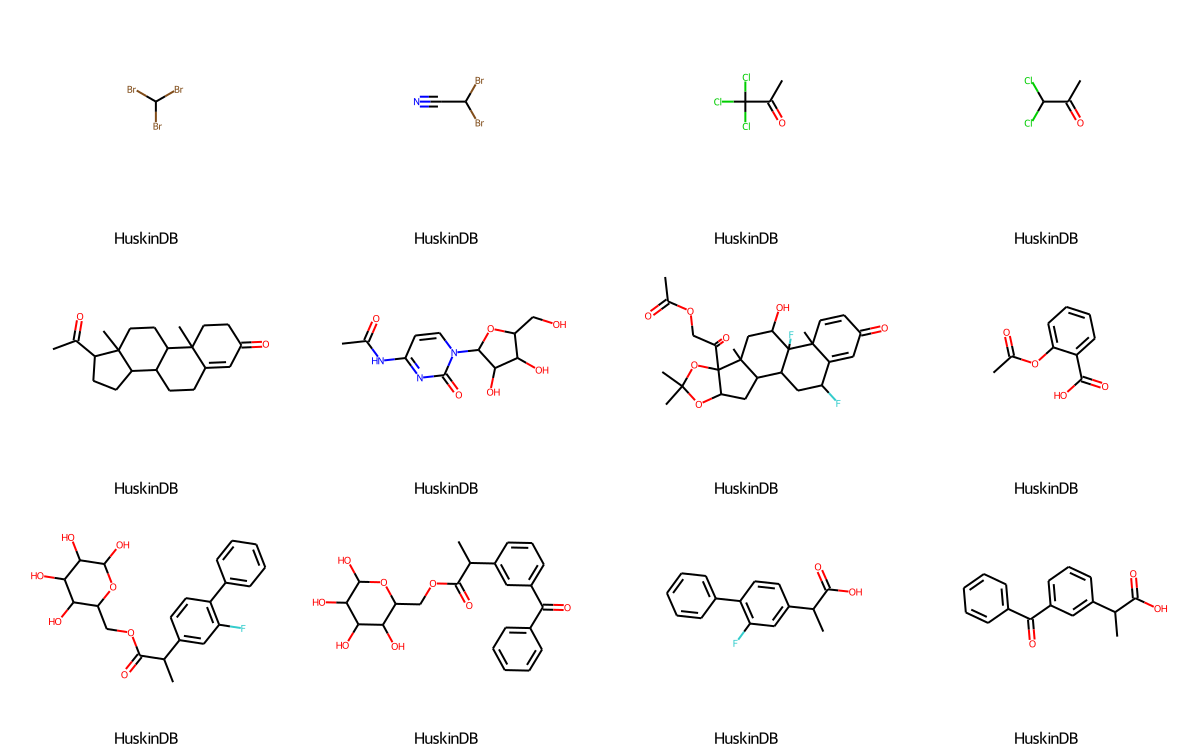

In [4]:
# Show first 12 reference molecules
ref_mols = []
ref_legends = []
for _, row in ref_df.head(12).iterrows():
    mol = Chem.MolFromSmiles(row['SMILES'])
    if mol:
        ref_mols.append(mol)
        ref_legends.append(row['source'])

print('First 12 reference compounds (skin permeability dataset):')
img = MolsToGridImage(ref_mols, molsPerRow=4, subImgSize=(300,250), legends=ref_legends)
display(img)
with open(f'{results_dir}/reference_molecules.png', 'wb') as f:
    f.write(img.data)

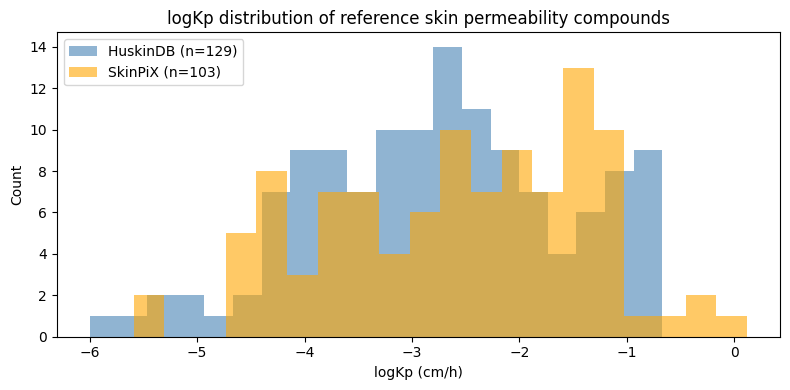

HuskinDB logKp: mean=-2.77, range=[-6.00, -0.67]
SkinPiX logKp:  mean=-2.56, range=[-5.59, 0.12]


In [5]:
# logKp distribution of reference compounds
huskin_logkp = huskin['logKp_(cm/h)_median'].dropna()
skinpix_logkp = skinpix['logKp_(cm/h)'].dropna()

fig, ax = plt.subplots(figsize=(8,4))
ax.hist(huskin_logkp, bins=20, alpha=0.6, label=f'HuskinDB (n={len(huskin_logkp)})', color='steelblue')
ax.hist(skinpix_logkp, bins=20, alpha=0.6, label=f'SkinPiX (n={len(skinpix_logkp)})', color='orange')
ax.set_xlabel('logKp (cm/h)')
ax.set_ylabel('Count')
ax.set_title('logKp distribution of reference skin permeability compounds')
ax.legend()
plt.tight_layout()
plt.savefig(f'{results_dir}/reference_logKp_distribution.png', dpi=150)
plt.show()
print(f'HuskinDB logKp: mean={huskin_logkp.mean():.2f}, range=[{huskin_logkp.min():.2f}, {huskin_logkp.max():.2f}]')
print(f'SkinPiX logKp:  mean={skinpix_logkp.mean():.2f}, range=[{skinpix_logkp.min():.2f}, {skinpix_logkp.max():.2f}]')

## 3. Generate Morgan fingerprints for reference compounds

In [6]:
ref_fps = []
valid_ref_smiles = []

for _, row in ref_df.iterrows():
    mol = Chem.MolFromSmiles(row['SMILES'])
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
        ref_fps.append(fp)
        valid_ref_smiles.append(row['SMILES'])

print(f'Valid reference fingerprints: {len(ref_fps)}')

Valid reference fingerprints: 214


## 4. Load ChEMBL building blocks

In [7]:
bb_path = '/home/nubar/Downloads/Internship_Chemoinfo/01_data/standardized/chembl_standardized_dedup.smi'

print('Loading BB dataset...')
bbs = []
with open(bb_path) as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            bbs.append({'smiles': parts[0], 'chembl_id': parts[1]})

df_bbs = pd.DataFrame(bbs)
print(f'Loaded {len(df_bbs):,} building blocks')

Loading BB dataset...
Loaded 1,094,666 building blocks


## 5. Tanimoto similarity filtering

Each BB is compared to all reference compounds using Tanimoto similarity. BBs with maximum Tanimoto ≥ 0.8 are retained.

**Note:** This processes ~1 million compounds and takes 20-40 minutes.

In [8]:
THRESHOLD = 0.8

passing_smiles = []
passing_ids = []
passing_max_sim = []

print(f'Running Tanimoto filtering (threshold >= {THRESHOLD})...')

for _, row in tqdm(df_bbs.iterrows(), total=len(df_bbs), desc='Filtering'):
    mol = Chem.MolFromSmiles(row['smiles'])
    if mol is None:
        continue
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    sims = DataStructs.BulkTanimotoSimilarity(fp, ref_fps)
    max_sim = max(sims)
    if max_sim >= THRESHOLD:
        passing_smiles.append(row['smiles'])
        passing_ids.append(row['chembl_id'])
        passing_max_sim.append(round(max_sim, 4))

df_focused = pd.DataFrame({
    'smiles': passing_smiles,
    'chembl_id': passing_ids,
    'max_tanimoto': passing_max_sim
})

print(f'\nDone!')
print(f'BBs passing Tanimoto >= {THRESHOLD}: {len(df_focused)}')
print(f'Retention rate: {len(df_focused)/len(df_bbs)*100:.2f}%')

Running Tanimoto filtering (threshold >= 0.8)...


Filtering: 100%|██████████| 1094666/1094666 [03:09<00:00, 5765.86it/s]


Done!
BBs passing Tanimoto >= 0.8: 470
Retention rate: 0.04%


## 6. Visualize focused BB set

First 12 focused BBs selected by Tanimoto filtering:


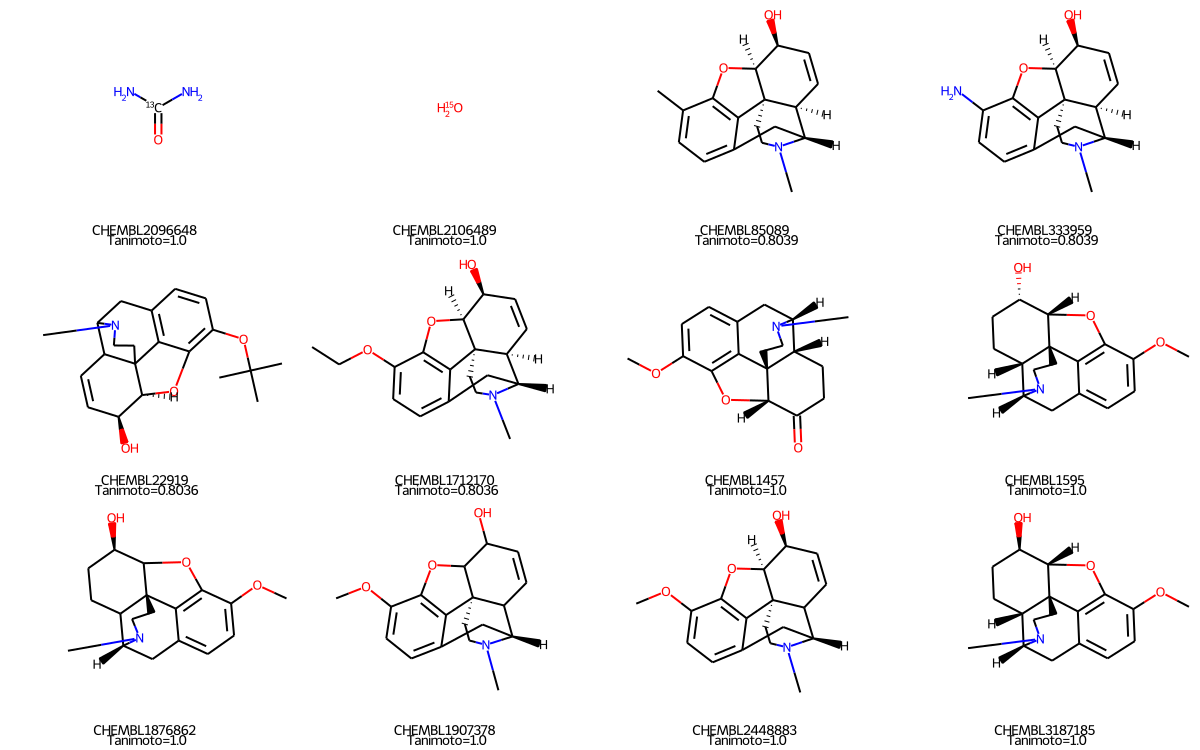

In [9]:
# Show first 12 focused BBs
focused_mols = []
focused_legends = []
for _, row in df_focused.head(12).iterrows():
    mol = Chem.MolFromSmiles(row['smiles'])
    if mol:
        focused_mols.append(mol)
        focused_legends.append(f"{row['chembl_id']}\nTanimoto={row['max_tanimoto']}")

print('First 12 focused BBs selected by Tanimoto filtering:')
img = MolsToGridImage(focused_mols, molsPerRow=4, subImgSize=(300,250), legends=focused_legends)
display(img)
with open(f'{results_dir}/focused_bbs.png', 'wb') as f:
    f.write(img.data)

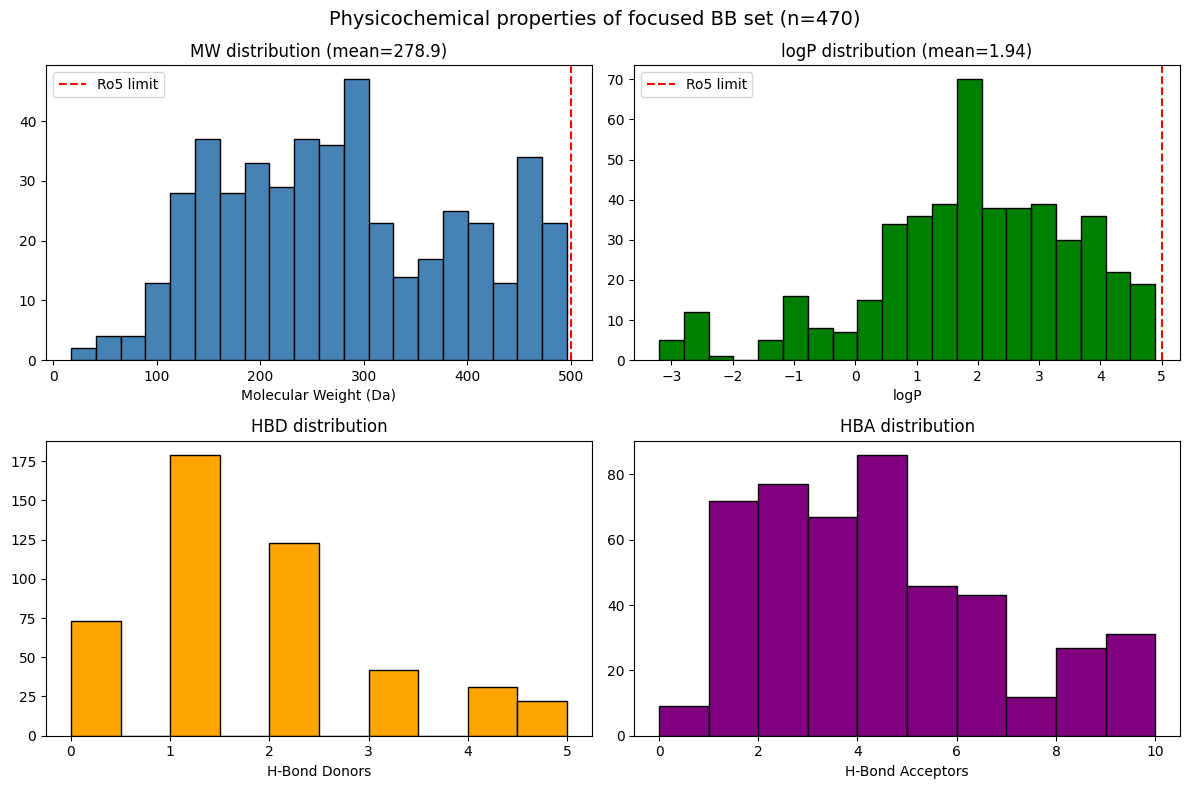

In [10]:
# Property distribution of focused BBs
mws, logps, hbds, hbas = [], [], [], []
for smi in df_focused['smiles']:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        mws.append(Descriptors.MolWt(mol))
        logps.append(Descriptors.MolLogP(mol))
        hbds.append(rdMolDescriptors.CalcNumHBD(mol))
        hbas.append(rdMolDescriptors.CalcNumHBA(mol))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].hist(mws, bins=20, color='steelblue', edgecolor='black')
axes[0,0].set_xlabel('Molecular Weight (Da)')
axes[0,0].set_title(f'MW distribution (mean={sum(mws)/len(mws):.1f})')
axes[0,0].axvline(x=500, color='red', linestyle='--', label='Ro5 limit')
axes[0,0].legend()

axes[0,1].hist(logps, bins=20, color='green', edgecolor='black')
axes[0,1].set_xlabel('logP')
axes[0,1].set_title(f'logP distribution (mean={sum(logps)/len(logps):.2f})')
axes[0,1].axvline(x=5, color='red', linestyle='--', label='Ro5 limit')
axes[0,1].legend()

axes[1,0].hist(hbds, bins=10, color='orange', edgecolor='black')
axes[1,0].set_xlabel('H-Bond Donors')
axes[1,0].set_title('HBD distribution')

axes[1,1].hist(hbas, bins=10, color='purple', edgecolor='black')
axes[1,1].set_xlabel('H-Bond Acceptors')
axes[1,1].set_title('HBA distribution')

plt.suptitle('Physicochemical properties of focused BB set (n=470)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{results_dir}/focused_bbs_properties.png', dpi=150)
plt.show()

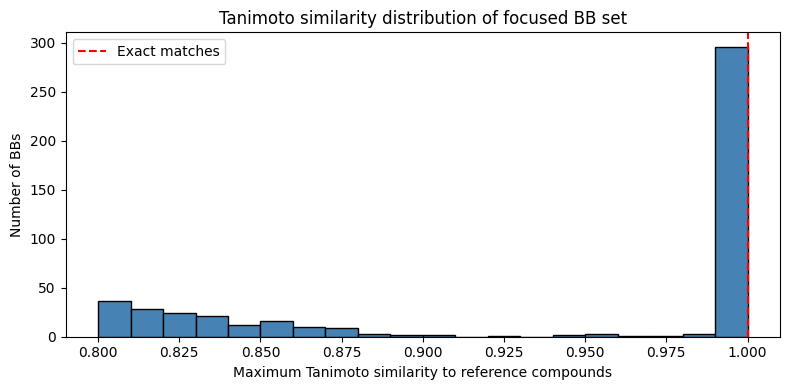

Exact matches (Tanimoto=1.0): 296
Near-identical (Tanimoto>=0.9): 309


In [11]:
# Tanimoto similarity distribution
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(df_focused['max_tanimoto'], bins=20, color='steelblue', edgecolor='black')
ax.set_xlabel('Maximum Tanimoto similarity to reference compounds')
ax.set_ylabel('Number of BBs')
ax.set_title('Tanimoto similarity distribution of focused BB set')
ax.axvline(x=1.0, color='red', linestyle='--', label='Exact matches')
ax.legend()
plt.tight_layout()
plt.savefig(f'{results_dir}/tanimoto_distribution.png', dpi=150)
plt.show()
print(f'Exact matches (Tanimoto=1.0): {(df_focused["max_tanimoto"]==1.0).sum()}')
print(f'Near-identical (Tanimoto>=0.9): {(df_focused["max_tanimoto"]>=0.9).sum()}')

## 7. Synt-On classification results

The focused 470 BBs were classified using the Synt-On classifier.

In [12]:
bbmode_path = '/home/nubar/Downloads/Internship_Chemoinfo/03_synthon/outputs/skin_focused/skin_focused_BBmode.smi'
notclass_path = '/home/nubar/Downloads/Internship_Chemoinfo/03_synthon/outputs/skin_focused/skin_focused_NotClassified'

classified = []
with open(bbmode_path) as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 4:
            try:
                n_synthons = int(parts[-1])  # last element is always the count
                smiles = parts[0]
                chembl_id = parts[1]
                bb_class = parts[2]
                classified.append({
                    'smiles': smiles,
                    'chembl_id': chembl_id,
                    'bb_class': bb_class,
                    'n_synthons': n_synthons
                })
            except ValueError:
                continue  # skip malformed lines

df_classified = pd.DataFrame(classified)

with open(notclass_path) as f:
    not_classified = sum(1 for line in f if line.strip())

print(f'Input BBs:               470')
print(f'Successfully classified: {len(df_classified)} ({len(df_classified)/470*100:.1f}%)')
print(f'Not classified:          {not_classified} ({not_classified/470*100:.1f}%)')
print(f'Total synthons generated: 597')

Input BBs:               470
Successfully classified: 340 (72.3%)
Not classified:          120 (25.5%)
Total synthons generated: 597


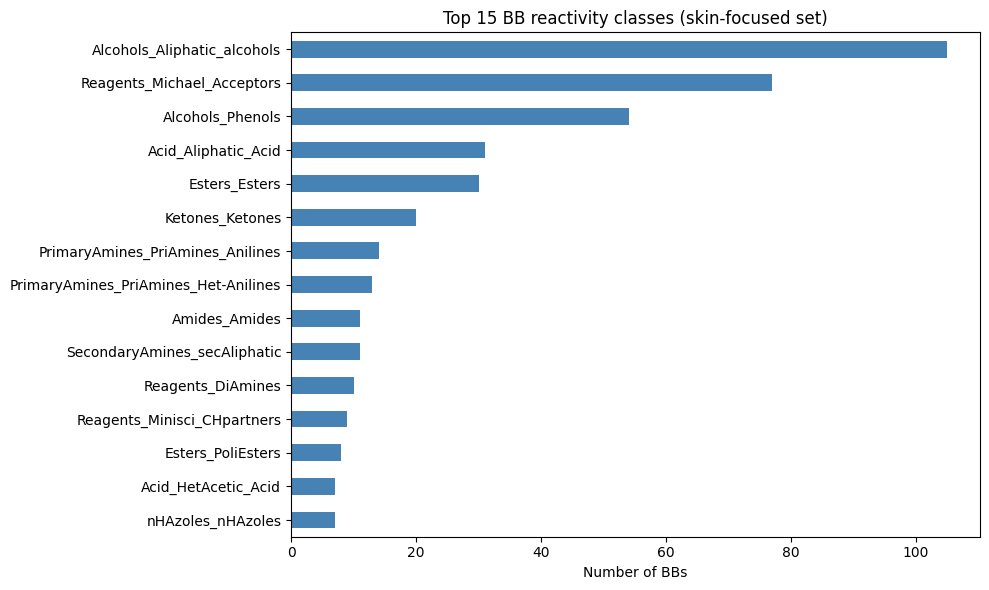

In [13]:
# BB class distribution
all_classes = []
for cls in df_classified['bb_class']:
    all_classes.extend(cls.split(','))

class_counts = pd.Series(all_classes).value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
class_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of BBs')
ax.set_title('Top 15 BB reactivity classes (skin-focused set)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{results_dir}/bb_class_distribution.png', dpi=150)
plt.show()

First 12 classified BBs:


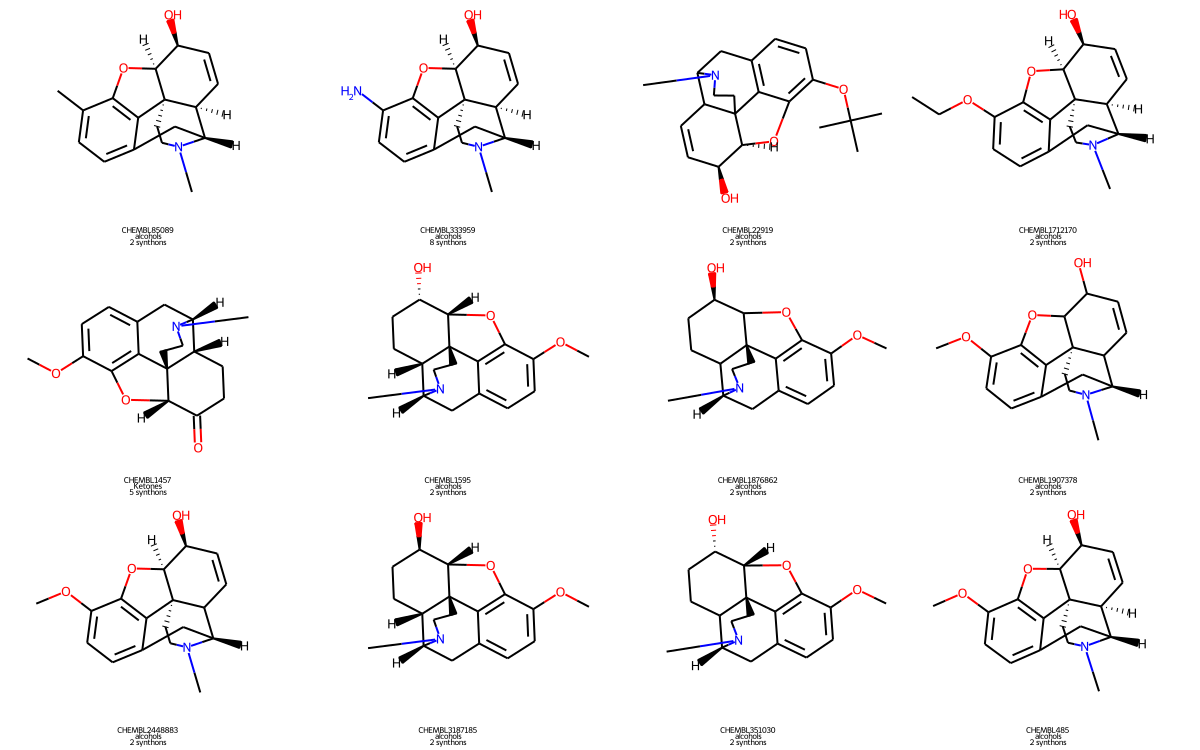

In [14]:
# Show first 12 classified BBs
class_mols = []
class_legends = []
for _, row in df_classified.head(12).iterrows():
    mol = Chem.MolFromSmiles(row['smiles'])
    if mol:
        class_mols.append(mol)
        cls_short = row['bb_class'].split(',')[0].split('_')[-1]
        class_legends.append(f"{row['chembl_id']}\n{cls_short}\n{row['n_synthons']} synthons")

print('First 12 classified BBs:')
img = MolsToGridImage(class_mols, molsPerRow=4, subImgSize=(300,250), legends=class_legends)
display(img)
with open(f'{results_dir}/classified_bbs.png', 'wb') as f:
    f.write(img.data)

## 8. Enumerated library analysis

1,047 new molecules were generated by combining compatible synthons.

Total enumerated products: 1047

First 12 enumerated products:


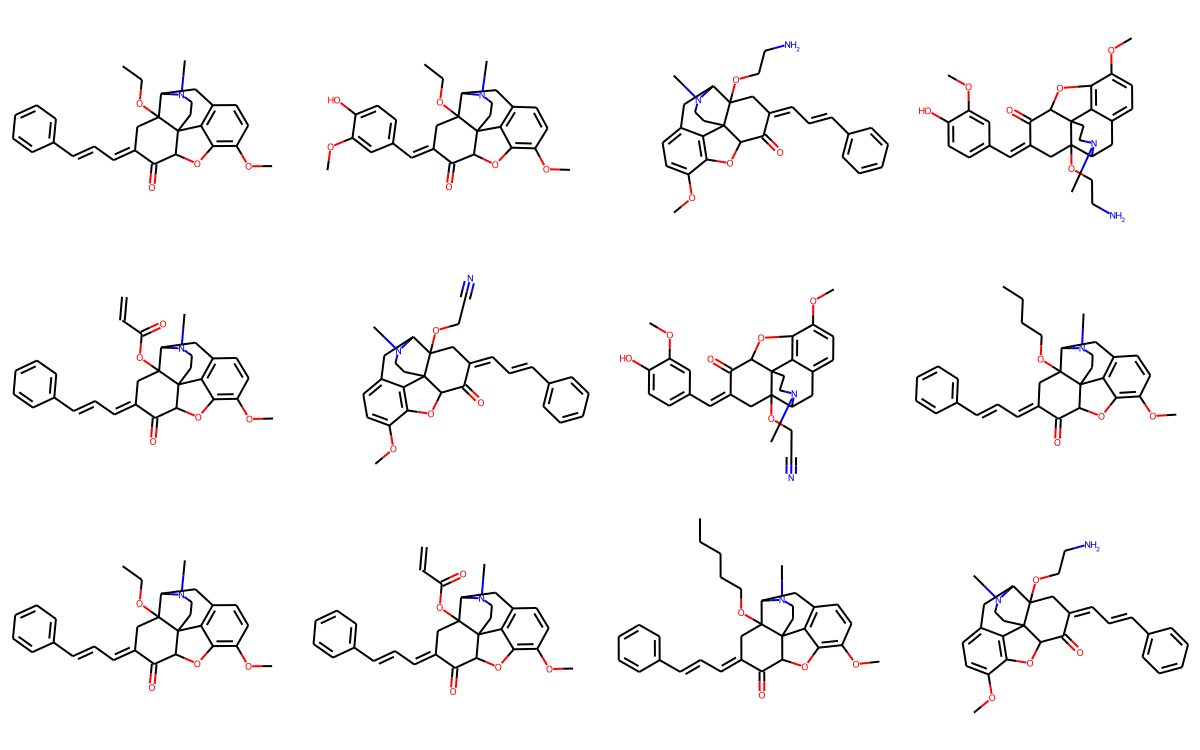

In [15]:
enum_path = '/home/nubar/Downloads/Internship_Chemoinfo/03_synthon/outputs/skin_focused_enumeration/FinalOut_allEnumeratedCompounds_DuplicatesCanBePresent.smi'

enum_mols = []
enum_smiles = []
with open(enum_path) as f:
    for line in f:
        smi = line.strip().split()[0]
        mol = Chem.MolFromSmiles(smi)
        if mol:
            enum_mols.append(mol)
            enum_smiles.append(smi)

print(f'Total enumerated products: {len(enum_mols)}')

# Show first 12
print('\nFirst 12 enumerated products:')
img = MolsToGridImage(enum_mols[:12], molsPerRow=4, subImgSize=(300,250))
display(img)
with open(f'{results_dir}/enumerated_products_sample.png', 'wb') as f:
    f.write(img.data)

In [16]:
# Property distribution of enumerated library
lib_mws, lib_logps, lib_hbds, lib_hbas, lib_tpsa = [], [], [], [], []

for mol in tqdm(enum_mols, desc='Computing properties'):
    lib_mws.append(Descriptors.MolWt(mol))
    lib_logps.append(Descriptors.MolLogP(mol))
    lib_hbds.append(rdMolDescriptors.CalcNumHBD(mol))
    lib_hbas.append(rdMolDescriptors.CalcNumHBA(mol))
    lib_tpsa.append(rdMolDescriptors.CalcTPSA(mol))

# Ro5 compliance
ro5_pass = sum(1 for mw, lp, hbd, hba in zip(lib_mws, lib_logps, lib_hbds, lib_hbas)
               if mw<=500 and lp<=5 and hbd<=5 and hba<=10)

print(f'Library size: {len(enum_mols)}')
print(f'Ro5 compliant: {ro5_pass} ({ro5_pass/len(enum_mols)*100:.1f}%)')
print(f'\nMW:   mean={sum(lib_mws)/len(lib_mws):.1f}, range=[{min(lib_mws):.1f}, {max(lib_mws):.1f}]')
print(f'logP: mean={sum(lib_logps)/len(lib_logps):.2f}, range=[{min(lib_logps):.2f}, {max(lib_logps):.2f}]')
print(f'TPSA: mean={sum(lib_tpsa)/len(lib_tpsa):.1f}, range=[{min(lib_tpsa):.1f}, {max(lib_tpsa):.1f}]')

Computing properties: 100%|██████████| 1047/1047 [00:00<00:00, 3961.58it/s]

Library size: 1047
Ro5 compliant: 851 (81.3%)

MW:   mean=460.9, range=[326.3, 499.7]
logP: mean=3.61, range=[-1.53, 6.45]
TPSA: mean=104.6, range=[48.0, 194.6]


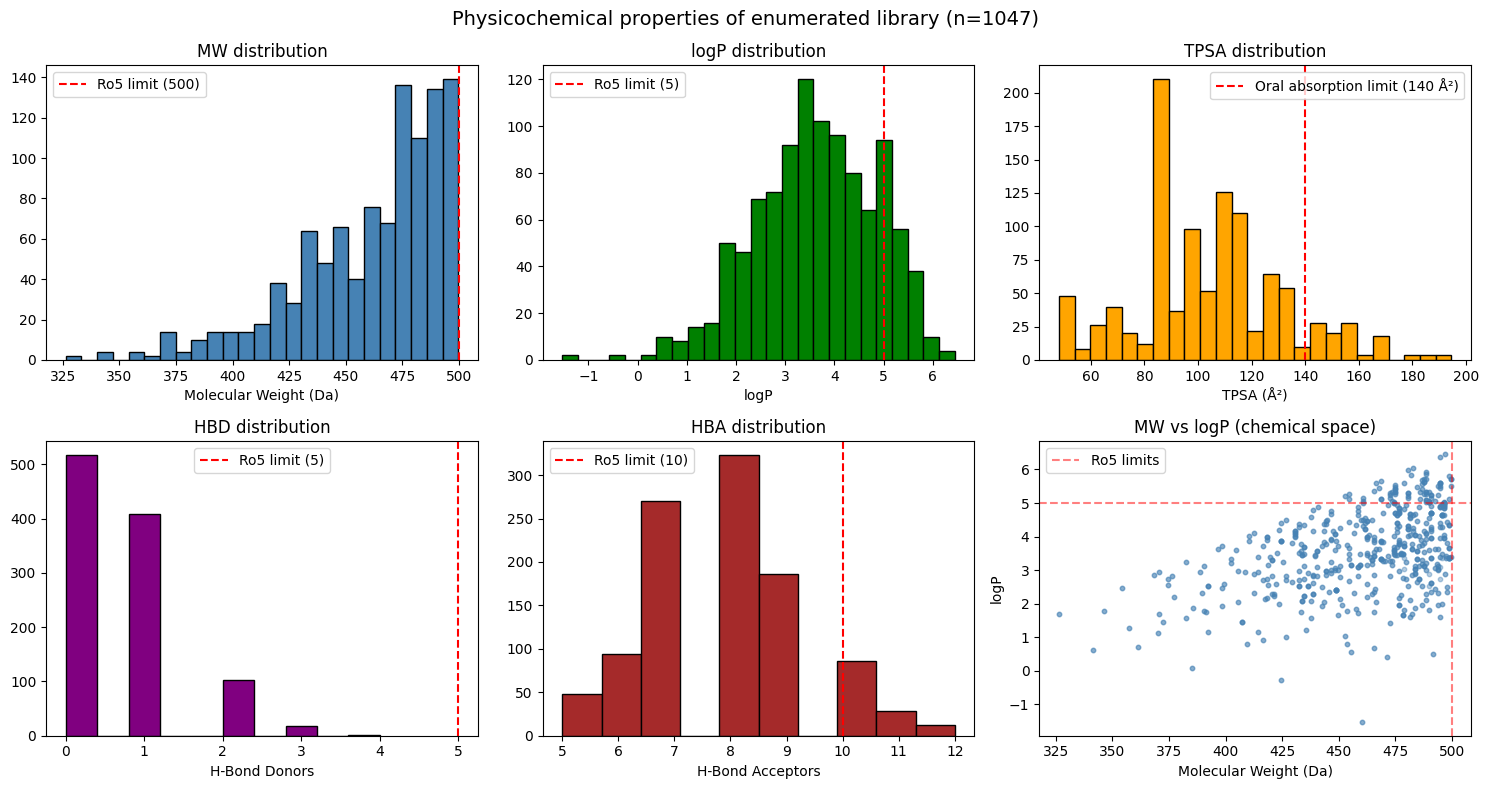

In [17]:
# Property distribution plots for enumerated library
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0,0].hist(lib_mws, bins=25, color='steelblue', edgecolor='black')
axes[0,0].axvline(x=500, color='red', linestyle='--', label='Ro5 limit (500)')
axes[0,0].set_xlabel('Molecular Weight (Da)')
axes[0,0].set_title('MW distribution')
axes[0,0].legend()

axes[0,1].hist(lib_logps, bins=25, color='green', edgecolor='black')
axes[0,1].axvline(x=5, color='red', linestyle='--', label='Ro5 limit (5)')
axes[0,1].set_xlabel('logP')
axes[0,1].set_title('logP distribution')
axes[0,1].legend()

axes[0,2].hist(lib_tpsa, bins=25, color='orange', edgecolor='black')
axes[0,2].axvline(x=140, color='red', linestyle='--', label='Oral absorption limit (140 Å²)')
axes[0,2].set_xlabel('TPSA (Å²)')
axes[0,2].set_title('TPSA distribution')
axes[0,2].legend()

axes[1,0].hist(lib_hbds, bins=10, color='purple', edgecolor='black')
axes[1,0].axvline(x=5, color='red', linestyle='--', label='Ro5 limit (5)')
axes[1,0].set_xlabel('H-Bond Donors')
axes[1,0].set_title('HBD distribution')
axes[1,0].legend()

axes[1,1].hist(lib_hbas, bins=10, color='brown', edgecolor='black')
axes[1,1].axvline(x=10, color='red', linestyle='--', label='Ro5 limit (10)')
axes[1,1].set_xlabel('H-Bond Acceptors')
axes[1,1].set_title('HBA distribution')
axes[1,1].legend()

# MW vs logP scatter
axes[1,2].scatter(lib_mws, lib_logps, alpha=0.4, color='steelblue', s=10)
axes[1,2].axvline(x=500, color='red', linestyle='--', alpha=0.5)
axes[1,2].axhline(y=5, color='red', linestyle='--', alpha=0.5, label='Ro5 limits')
axes[1,2].set_xlabel('Molecular Weight (Da)')
axes[1,2].set_ylabel('logP')
axes[1,2].set_title('MW vs logP (chemical space)')
axes[1,2].legend()

plt.suptitle(f'Physicochemical properties of enumerated library (n={len(enum_mols)})', fontsize=14)
plt.tight_layout()
plt.savefig(f'{results_dir}/library_properties.png', dpi=150)
plt.show()

## 9. Skin permeability predictions

100 enumerated compounds were submitted to the ISIDA skin permeability predictor. Predicted logKp values (cm/h) are analyzed below.

In [18]:
df_pred = pd.read_csv(
    '/home/nubar/Downloads/Internship_Chemoinfo/04_results/skin_permeability_predictions.csv',
    sep=';',
    quotechar='"'
)

print(f'Total predictions: {len(df_pred)}')
print(f'\nPredicted logKp statistics:')
print(df_pred['Average on AD'].describe().round(3))
print(f'\nPrediction confidence:')
print(df_pred['Prediction confidence'].value_counts())

Total predictions: 100

Predicted logKp statistics:
count    100.000
mean      -3.102
std        0.036
min       -3.212
25%       -3.121
50%       -3.101
75%       -3.074
max       -3.035
Name: Average on AD, dtype: float64

Prediction confidence:
Prediction confidence
Good       96
Low         2
Average     2
Name: count, dtype: int64


Skin Permeability Prediction Model

In [22]:
print('=== FULL PREDICTION STATISTICS ===\n')
print(f'Total compounds predicted: {len(df_all)}')
print(f'\nlogKp statistics:')
print(df_all['Average on AD'].describe().round(3))
print(f'\nPrediction confidence:')
print(df_all['Prediction confidence'].value_counts())
print(f'\nNumber of applied models:')
print(df_all['# of Applied models'].value_counts().sort_index())

=== FULL PREDICTION STATISTICS ===

Total compounds predicted: 1047

logKp statistics:
count    1047.000
mean       -3.092
std         0.054
min        -3.265
25%        -3.125
50%        -3.095
75%        -3.067
max        -2.689
Name: Average on AD, dtype: float64

Prediction confidence:
Prediction confidence
Good       758
Optimal    171
Average     76
Low         42
Name: count, dtype: int64

Number of applied models:
# of Applied models
2    118
3     65
4    691
5    173
Name: count, dtype: int64


In [23]:
# Compare with reference dataset
huskin = pd.read_csv('/home/nubar/Downloads/Internship_Chemoinfo/01_data/raw/huskin_depot.csv')
skinpix = pd.read_csv('/home/nubar/Downloads/Internship_Chemoinfo/01_data/raw/skinpix_depot.csv')

ref_logkp = pd.concat([
    huskin['logKp_(cm/h)_median'].dropna(),
    skinpix['logKp_(cm/h)'].dropna()
])

print('=== REFERENCE DATASET logKp ===')
print(ref_logkp.describe().round(3))
print(f'\n=== LIBRARY PREDICTED logKp ===')
print(df_all['Average on AD'].describe().round(3))
print(f'\nDifference in means: {df_all["Average on AD"].mean() - ref_logkp.mean():.3f} cm/h')

=== REFERENCE DATASET logKp ===
count    232.000
mean      -2.677
std        1.201
min       -6.000
25%       -3.620
50%       -2.600
75%       -1.690
max        0.120
dtype: float64

=== LIBRARY PREDICTED logKp ===
count    1047.000
mean       -3.092
std         0.054
min        -3.265
25%        -3.125
50%        -3.095
75%        -3.067
max        -2.689
Name: Average on AD, dtype: float64

Difference in means: -0.414 cm/h


In [24]:
# Find most permeable compound
best_idx = df_all['Average on AD'].idxmax()
print(f'Most permeable compound:')
print(f'Compound ID: {df_all.loc[best_idx, "Compound Id"]}')
print(f'logKp: {df_all.loc[best_idx, "Average on AD"]}')
print(f'Confidence: {df_all.loc[best_idx, "Prediction confidence"]}')

# Find least permeable
worst_idx = df_all['Average on AD'].idxmin()
print(f'\nLeast permeable compound:')
print(f'Compound ID: {df_all.loc[worst_idx, "Compound Id"]}')
print(f'logKp: {df_all.loc[worst_idx, "Average on AD"]}')
print(f'Confidence: {df_all.loc[worst_idx, "Prediction confidence"]}')

Most permeable compound:
Compound ID: 60
logKp: -2.689
Confidence: Low

Least permeable compound:
Compound ID: 93
logKp: -3.265
Confidence: Good


In [26]:
# Look at the 5 individual model predictions
print("=== Individual model predictions (first 5 rows) ===\n")
cols = ['Compound Id', 'Model1 AD', 'Model1', 'Model2 AD', 'Model2', 
        'Model3 AD', 'Model3', 'Model4 AD', 'Model4', 
        'Model5 AD', 'Model5', 'Average on AD', '# of Applied models', 
        'Prediction confidence']
print(df_all[cols].head().to_string())

print("\n=== How often each model is in AD ===")
for i in range(1, 6):
    ad_col = f'Model{i} AD'
    true_count = (df_all[ad_col] == True).sum()
    print(f'Model{i}: {true_count}/1047 in AD ({true_count/1047*100:.1f}%)')

=== Individual model predictions (first 5 rows) ===

   Compound Id  Model1 AD    Model1  Model2 AD    Model2  Model3 AD    Model3  Model4 AD    Model4  Model5 AD    Model5  Average on AD  # of Applied models Prediction confidence
0            1      False -3.114385       True -3.093147       True -3.049104      False -3.037273       True -2.982066         -3.041                    3                  Good
1            2      False -3.102647       True -3.122855       True -3.051371      False -3.027845       True -2.964731         -3.046                    3                  Good
2            3      False -3.131821       True -3.136712       True -3.048197      False -3.059939       True -3.013998         -3.066                    3                  Good
3            4      False -3.108407       True -3.155267       True -3.052042      False -3.037909       True -3.000271         -3.069                    3                  Good
4            5      False -3.080824       True -3.111582 

In [27]:
# How much do the 5 models agree with each other?
print("=== Agreement between models ===\n")

# Calculate std deviation across all 5 model predictions for each compound
model_cols = ['Model1', 'Model2', 'Model3', 'Model4', 'Model5']
df_all['prediction_std'] = df_all[model_cols].std(axis=1)

print(f'Mean std deviation across models: {df_all["prediction_std"].mean():.4f}')
print(f'Max std deviation: {df_all["prediction_std"].max():.4f}')
print(f'Min std deviation: {df_all["prediction_std"].min():.4f}')

print(f'\n=== Most permeable compounds (top 5) ===')
top5 = df_all.nlargest(5, 'Average on AD')[['Compound Id', 'Average on AD', 'Prediction confidence', '# of Applied models']]
print(top5.to_string())

print(f'\n=== Least permeable compounds (bottom 5) ===')
bot5 = df_all.nsmallest(5, 'Average on AD')[['Compound Id', 'Average on AD', 'Prediction confidence', '# of Applied models']]
print(bot5.to_string())

print(f'\n=== Optimal confidence compounds ===')
optimal = df_all[df_all['Prediction confidence'] == 'Optimal']
print(f'Count: {len(optimal)}')
print(f'Mean logKp: {optimal["Average on AD"].mean():.3f}')
print(f'logKp range: {optimal["Average on AD"].min():.3f} to {optimal["Average on AD"].max():.3f}')

=== Agreement between models ===

Mean std deviation across models: 0.0990
Max std deviation: 0.2185
Min std deviation: 0.0258

=== Most permeable compounds (top 5) ===
     Compound Id  Average on AD Prediction confidence  # of Applied models
159           60         -2.689                   Low                    2
548           49         -2.689                   Low                    2
170           71         -2.765                   Low                    2
528           29         -2.765                   Low                    2
142           43         -2.768                   Low                    2

=== Least permeable compounds (bottom 5) ===
     Compound Id  Average on AD Prediction confidence  # of Applied models
192           93         -3.265                  Good                    4
146           47         -3.246                   Low                    2
329           30         -3.246                   Low                    2
41            42         -3.212    

In [28]:
# Check relationship between confidence and predicted logKp
print("=== Mean logKp by confidence level ===\n")
confidence_order = ['Optimal', 'Good', 'Average', 'Low']
for conf in confidence_order:
    subset = df_all[df_all['Prediction confidence'] == conf]
    if len(subset) > 0:
        print(f"{conf:10s}: n={len(subset):4d}, mean logKp={subset['Average on AD'].mean():.3f}, "
              f"range=[{subset['Average on AD'].min():.3f}, {subset['Average on AD'].max():.3f}]")

=== Mean logKp by confidence level ===

Optimal   : n= 171, mean logKp=-3.053, range=[-3.148, -2.948]
Good      : n= 758, mean logKp=-3.104, range=[-3.265, -2.866]
Average   : n=  76, mean logKp=-3.074, range=[-3.154, -2.932]
Low       : n=  42, mean logKp=-3.064, range=[-3.246, -2.689]


In [29]:
ro5_pass = sum(1 for mw, lp, hbd, hba in zip(lib_mws, lib_logps, lib_hbds, lib_hbas)
               if mw<=500 and lp<=5 and hbd<=5 and hba<=10)
print(f'Ro5 compliant: {ro5_pass} ({ro5_pass/len(enum_mols)*100:.1f}%)')
print(f'MW: mean={sum(lib_mws)/len(lib_mws):.1f}, min={min(lib_mws):.1f}, max={max(lib_mws):.1f}')
print(f'logP: mean={sum(lib_logps)/len(lib_logps):.2f}')
print(f'TPSA: mean={sum(lib_tpsa)/len(lib_tpsa):.1f}')

Ro5 compliant: 851 (81.3%)
MW: mean=460.9, min=326.3, max=499.7
logP: mean=3.61
TPSA: mean=104.6


8 most frequent Bemis Murcko Scaffolds in the Enumarated Library


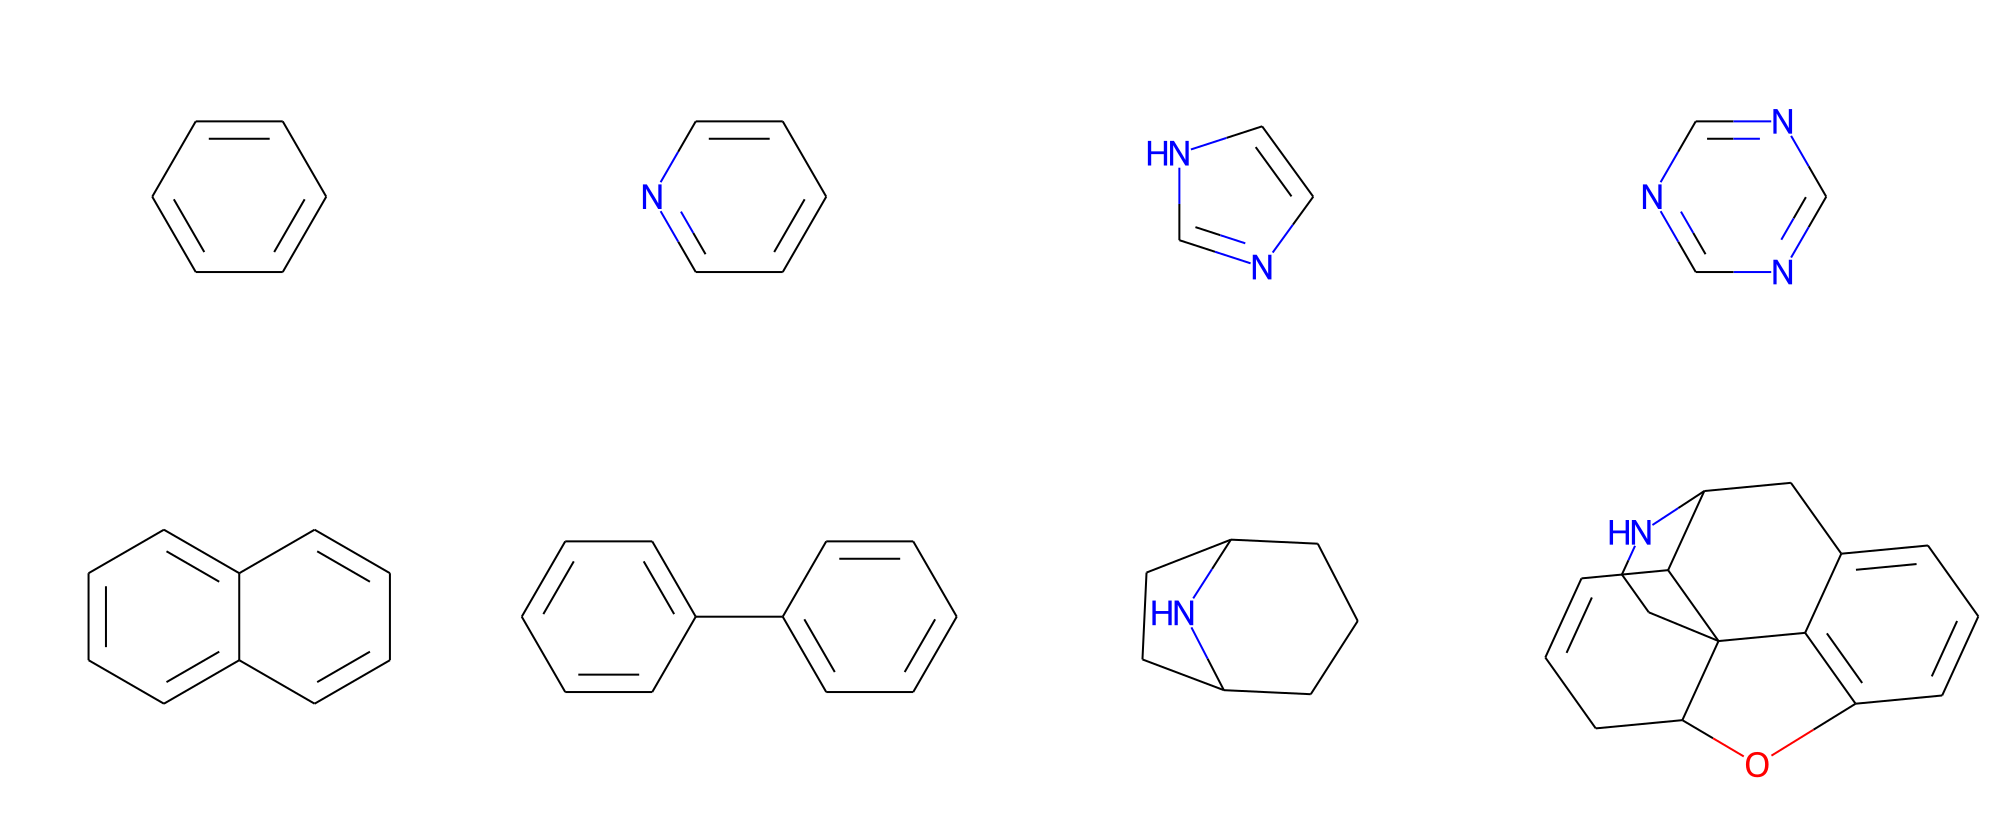

Saved to /home/nubar/Downloads/Internship_Chemoinfo/04_results/bemis_murcko_scaffolds_8.png


In [1]:
from rdkit import Chem
from rdkit.Chem.Draw import MolsToGridImage
from IPython.display import display

scaffolds = [
    'c1ccccc1',
    'c1ccncc1',
    'c1c[nH]cn1',
    'c1ncncn1',
    'c1ccc2ccccc2c1',
    'c1ccc(-c2ccccc2)cc1',
    'C1CC2CCC(C1)N2',
    'C1=CC2C3Cc4cccc5c4C2(CCN3)C(C1)O5',
]

mols = [Chem.MolFromSmiles(smi) for smi in scaffolds]

img = MolsToGridImage(
    mols,
    molsPerRow=4,
    subImgSize=(500, 420),
    legends=[]
)
display(img)

output = '/home/nubar/Downloads/Internship_Chemoinfo/04_results/bemis_murcko_scaffolds_8.png'
with open(output, 'wb') as f:
    f.write(img.data)
print(f'Saved to {output}')